# Task 2 - Distillation Attack

## 模型窃取攻击
- 如实验说明中介绍，简单的模型窃取攻击可能有2种loss设计方式：
    1. 利用平方差函数衡量窃取模型和目标模型的输出差异，然后通过训练最小化这一差异
    2. 通过softmax归一化窃取模型和目标模型的输出，用KL散度衡量归一化后两者的输出差异，然后通过训练最小化这一差异
- 下面请大家按照上述2个设计思路，实现模型窃取攻击
    1. 对于形式一而言，大家在计算loss时可能用到的函数有：
        - torch.norm(input, p, dim)：计算input的L_p范数
            - input：需要计算L_p范数的Tensor类型数据
            - p：L_p范数的p的取值，当前场景下可以直接令p=2
            - dim: L_p范数的计算维度，如果有给输入值，即只对dim对应维度的数据计算L_p范数
        - torch.mean(input, dim)：计算input所有元素的平均值
            - input：需要计算均值的Tensor类型数据
            - dim: 求和函数的计算维度，如果有给输入值，则只对dim对应维度的数据求均值
    1. 对于形式二而言，大家在计算loss时可能用到的函数有：
        - torch.softmax(input, dim)：计算input的softmax激活值
            - input：需要计算softmax激活值的Tensor类型数据
            - dim: softmax函数的计算维度，如果有给输入值，即只对dim对应维度的数据计算softmax激活值
        - torch.sum(input, dim)：计算input所有元素的和
            - input：需要求和的Tensor类型数据
            - dim: 求和函数的计算维度，如果有给输入值，则只对dim对应维度的数据求和
        - torch.mean(input)：计算input所有元素的平均值，详细介绍同上
        - torch.log(input): 计算input种每个元素的对数值
            - input：需要求对数的Tensor类型数据
    3. 除此之外，steal_model和之前的模型训练过程是一致的，先用优化器清零梯度，然后计算loss并反向传播梯度，最后用优化器更新模型。具体使用的函数这里不再介绍。

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from utils_week13 import LeNet5, evaluate_dataloader


In [2]:
batch_size = 16
learning_rate = 1e-3
epochs = 10
query_budgets = [1000, 5000, 10000]
tau = 2.0


## 数据加载与预处理

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()

])

testset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True, drop_last=True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 8.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 219kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.97MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.32MB/s]


## 加载目标模型

In [5]:
target_model = LeNet5()
params = torch.load("./model/lenet5.pt", map_location="cpu")
target_model.load_state_dict(params)
target_model.eval()


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

## 准备查询数据集

In [6]:
def build_query_datasets(model, budgets, batch_size):
    datasets = {}
    model.eval()
    for budget in budgets:
        x_filename = f"MNIST_X_budget={budget}.npy"
        query_set_x = np.load(x_filename)
        
        query_pairs = []
        num_samples = query_set_x.shape[0]
        for i in range(0, num_samples, batch_size):
            if i + batch_size > num_samples:
                break
            
            # TODO: 从 query_set_x 中取出当前 batch 的数据，并再获取目标模型输出 logits
            batch_x = torch.from_numpy(query_set_x[i:i+batch_size]).float()
            with torch.no_grad():
                batch_y = model(batch_x)
        

            if batch_y is not None:
                query_pairs.append((batch_x, batch_y))
        datasets[budget] = query_pairs
        print(f"Budget={budget}, batches={len(query_pairs)}")
    return datasets


## 模型窃取攻击（L2 与 KL）

In [7]:
def train_steal_l2(query_set, epochs, lr):
    model = LeNet5()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for x, y in query_set:
            # TODO: 基于L2损失进行前向、反向传播和更新
            pred = model(x)
            loss = torch.nn.functional.mse_loss(pred, y) # Mean Squared Error Loss, 默认参数下等价于L2损失
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

def train_steal_kl(query_set, epochs, lr, tau):
    model = LeNet5()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for x, y in query_set:
            # TODO: 基于KL散度进行前向、反向传播和更新
            pred = model(x)
            pred_log_prob = torch.nn.functional.log_softmax(pred / tau, dim=1)
            target_prob = torch.nn.functional.softmax(y / tau, dim=1)
            loss = torch.nn.functional.kl_div(pred_log_prob, target_prob, reduction='batchmean') * (tau ** 2) # KL Divergence Loss with temperature scaling
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model


Budget=1000, batches=62
Budget=5000, batches=312
Budget=10000, batches=625
Budget=1000 | L2 Acc=0.9450 | KL Acc=0.9308
Budget=5000 | L2 Acc=0.9631 | KL Acc=0.9563
Budget=10000 | L2 Acc=0.9644 | KL Acc=0.9658


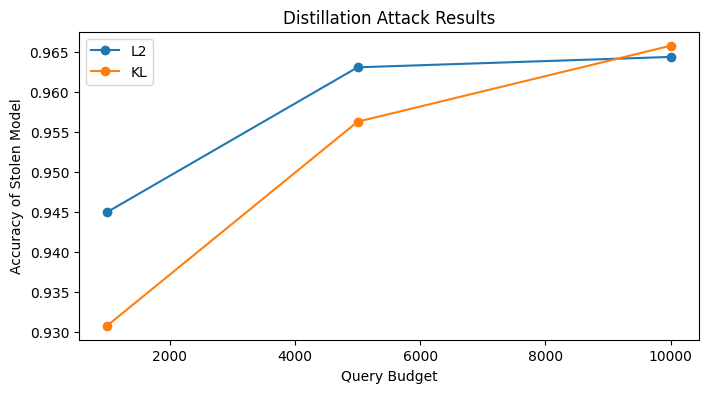

In [8]:
query_datasets = build_query_datasets(target_model, query_budgets, batch_size)

l2_results = []
kl_results = []

for budget in query_budgets:
    query_set = query_datasets[budget]
    steal_l2 = train_steal_l2(query_set, epochs, learning_rate)
    steal_kl = train_steal_kl(query_set, epochs, learning_rate, tau)

    l2_acc = evaluate_dataloader(steal_l2, test_loader, show_progress=False)
    kl_acc = evaluate_dataloader(steal_kl, test_loader, show_progress=False)

    l2_results.append(l2_acc)
    kl_results.append(kl_acc)
    print(f"Budget={budget} | L2 Acc={l2_acc:.4f} | KL Acc={kl_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(query_budgets, l2_results, marker="o", label="L2")
plt.plot(query_budgets, kl_results, marker="o", label="KL")
plt.xlabel("Query Budget")
plt.ylabel("Accuracy of Stolen Model")
plt.title("Distillation Attack Results")
plt.legend()
plt.show()
